#                                                               Titanic ML Track

**Contents**
- Task 1: Exploratory Data Analysis
- Task 2: Data Cleaning, Outlier Detection & Visualization
- Task 3: Logistic Regression — Predicting Survival

> 

> 

#### Task-01 - Exploratory Data Analysis
- This notebook performs an initial exploratory data analysis of the Titanic dataset. 
- The goal is to understand the dataset's structure, dimensions, data types, missing values, and basic statistical characteristics before applying any 
data preprocessing or machine learning techniques.

### 1. Import libraries

In [90]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

### 2. Load the dataset

In [91]:
titanic_data = pd.read_csv("../data/titanic.csv")
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### 3. Displaying top-5 rows

In [92]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 4. Displaying bottom-5 rows

In [93]:
titanic_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### 5. Checking the shape of the dataset

In [94]:
overall_shape = titanic_data.shape
print(f"Overall shape: {overall_shape}")
print(f"Total No.of rows: {overall_shape[0]}")
print(f"Total No.of cols: {overall_shape[1]}")

Overall shape: (891, 12)
Total No.of rows: 891
Total No.of cols: 12


### 6. Getting overall information about the dataset

In [95]:
titanic_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### 7. Checking the overall statistics of the data

In [96]:
titanic_data.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


### 8. Identifying missing values

In [97]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

> Conclusion: Missing values available in columns `Age` = 177 and `Cabin` = 687, `Embarked` = 2  

In [98]:
missing_values_percentage = (titanic_data.isnull().sum() / len(titanic_data)) * 100
missing_values_percentage[missing_values_percentage > 0]

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64

### 9. Identifying Numerical & Categorical Columns

In [99]:
numerical_columns = titanic_data.select_dtypes(include=np.number).columns
categorical_columns = titanic_data.select_dtypes(include="object").columns

print(f"Numerical Columns: {list(numerical_columns)}")
print(f"Categorical Columns: {list(categorical_columns)}")

Numerical Columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


### 10. Key Findings - Data Story

- The Titanic dataset contains 891 passenger records and 12 columns with both numerical and categorical features.
- The dataset contains missing values in `Age` (177), `Cabin` (687), and `Embarked` (2).
- Cabin has the highest amount of missing data, with approximately `77.1%` of its values missing.
- Age also contains a considerable amount of missing data, with approximately `19.9%` values missing.
- The numerical features include PassengerId, Survived, Pclass, Age, SibSp, Parch, and Fare, while Name, Sex, Ticket, Cabin, and Embarked are categorical/string features.
- Overall, the dataset provides useful passenger information but requires appropriate handling of missing values before applying machine learning models.

## Task 2: Data Cleaning, Outlier Detection & Visualization

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
titanic_cleaned = titanic_data.copy()

In [102]:
titanic_cleaned.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1. Handling Missing values

In [103]:
titanic_cleaned['Age'] = titanic_cleaned['Age'].fillna(titanic_cleaned['Age'].median())
titanic_cleaned['Embarked'] = titanic_cleaned['Embarked'].fillna(titanic_cleaned['Embarked'].mode()[0])
titanic_cleaned = titanic_cleaned.drop(columns=['Cabin'])

titanic_cleaned.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Justification
- Filled `Age` column with the `median` instead of the mean because Age has some extreme values (outliers) and the median isn't affected by them as much. 
- Filled Embarked with the mode since it's a category, so it makes sense to use the most common value. 
- Dropped Cabin entirely because 77% of it was missing — filling that much data would just be guessing, and it wouldn't be a reliable feature.

### 2. Outlier Detection

A. Boxplot

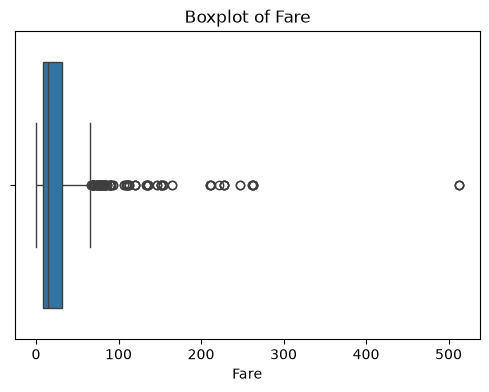

In [104]:
plt.figure(figsize=(6,4))
sns.boxplot(x=titanic_cleaned['Fare'])
plt.title('Boxplot of Fare')
plt.show()

B. Histogram

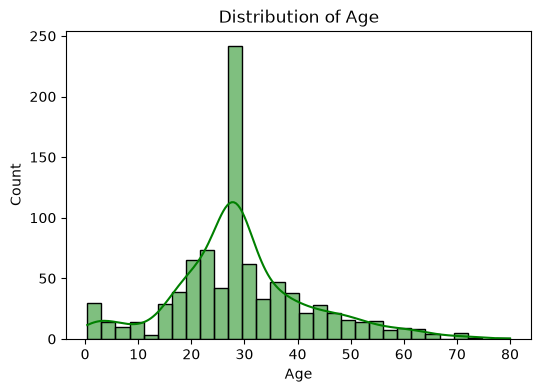

In [105]:
plt.figure(figsize=(6,4))
sns.histplot(titanic_cleaned['Age'], bins=30, kde=True, color="green")
plt.title('Distribution of Age')
plt.show()

C. Boxplot (Age by Survival):

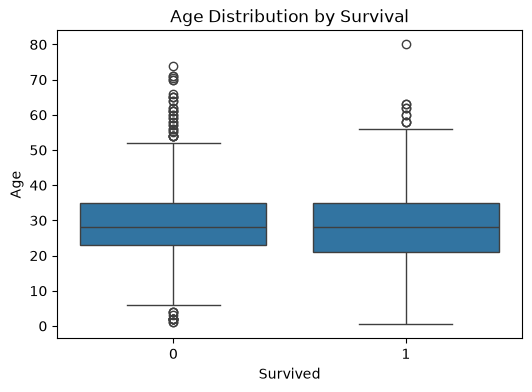

In [106]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Age', data=titanic_cleaned)
plt.title('Age Distribution by Survival')
plt.show()

D. Bar chart

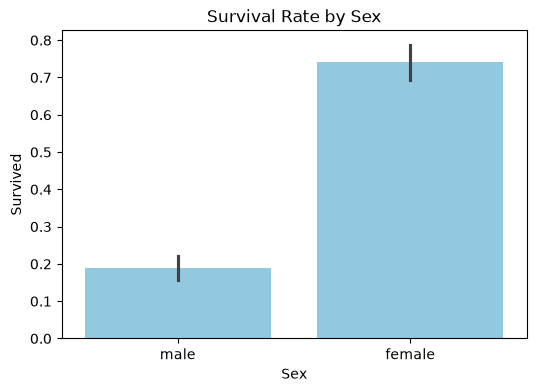

In [107]:
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=titanic_cleaned, color="skyblue")
plt.title('Survival Rate by Sex')
plt.show()

E. Correlation between features

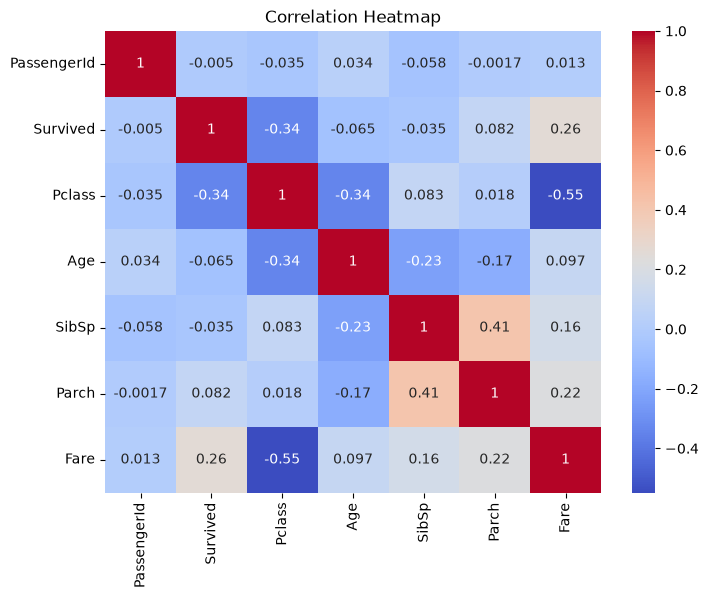

In [108]:
plt.figure(figsize=(8,6))
sns.heatmap(titanic_cleaned.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Key Insights
- By inspecting data `Sex` most affects `survival`. 
- The bar chart shows female passengers had a much higher survival rate than males, this matches the "women and children first" evacuation policy. P- class also seems important from the heatmap (-0.34), since it's negatively correlated with survival, meaning passengers in lower classes (like 3rd class) survived less often, probably because they had less access to lifeboats.

# Task 3: Logistic Regression — Predicting Titanic Survival

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

### 1. Dropping unnecessary columns

In [110]:
# Name, Ticket, PassengerId don't help a model predict survival — they're identifiers, not patterns
titanic_cleaned = titanic_cleaned.drop(columns=['Name', 'Ticket', 'PassengerId'])

In [111]:
titanic_cleaned.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 2. Encode categorical columns

In [112]:
titanic_cleaned = pd.get_dummies(titanic_cleaned, columns=['Sex', 'Embarked'], drop_first=True).astype(int)
titanic_cleaned.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22,1,0,7,1,0,1
1,1,1,38,1,0,71,0,0,0
2,1,3,26,0,0,7,0,0,1
3,1,1,35,1,0,53,0,0,1
4,0,3,35,0,0,8,1,0,1


### 3. Splitting features and Target

In [113]:
X = titanic_cleaned.drop(columns=['Survived'])
y = titanic_cleaned['Survived']

### 4. Data Split (Train = 80 and Test = 20)

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 5. Training the Machine Learning Model

In [115]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### 6. Evaluating Model Performance

In [116]:
y_predictions = model.predict(X_test)

In [126]:
accuracy = accuracy_score(y_test, y_predictions)
print(f"Accuracy: {accuracy:.2f} = {accuracy*100:.2f}%")

Accuracy: 0.81 = 81.01%


### 7. Confusion Matrix

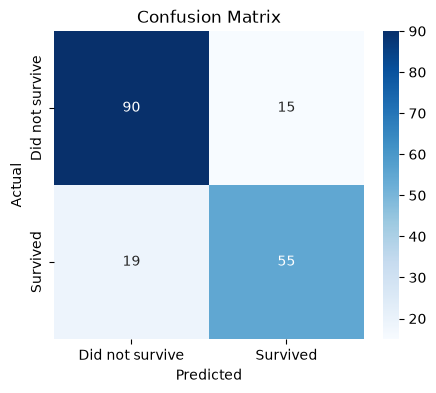

In [127]:
cm = confusion_matrix(y_test, y_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

> Results
- The confusion matrix shows four outcomes: how many passengers the model correctly said "did not survive" (top-left), correctly said "survived" (bottom-right), and where it got confused — predicting survival when they didn't (false positive) or predicting death when they actually survived (false negative). 

- Most of the predictions fall on the correct diagonal, which lines up with the ~81% accuracy score. The mistakes it does make tend to be predicting survival for men who died, since the model leans heavily on Sex as a signal.